# Problem Statement

The UCI News Aggregator dataset is a set of over 420,000 news articles that were compiled in 2014.  

Our goal for this analysis is to determine underlying trends among the articles to uncover commonalities and other links within the dataset using K-nearest neighbors, a machine learning technique that's usually used in analyzing unlabeled data.  However, in this case, it will be used to aid in further exploring the UCI News Aggregator dataset to uncover trends that we may not notice otherwise.

# Dictionary

- ID: the numeric ID of the article
- TITLE: the headline of the article
- URL: the URL of the article
- PUBLISHER: the publisher of the article
- CATEGORY: the category of the news item; one of:
    - e: entertainment
    - b: business
    - t: science and technology
    - m: health
- STORY: alphanumeric ID of the news story that the article discusses
- HOSTNAME: hostname where the article was posted
- TIMESTAMP: approximate timestamp of the article's publication, given in Unix time (seconds since midnight on Jan 1, 1970)

# Exploration

In the data exploration phase, we will cleanse the data to ensure suitable usage for modelling.

## Library Imports

We will import the NumPy, Pandas, Scikit-Learn Matplotlib, and Seaborn libraries to analyze, model and visualize our data.

Meanwhile, pickle and re will allow us to save our variables and perform internal operations within the system in which we perform this analysis.

In [1]:
# !pip install seaborn
# !pip install --upgrade pip

In [2]:
# Import the packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re

from sklearn.feature_extraction.text import CountVectorizer

import pickle

import warnings
warnings.filterwarnings("ignore")

# Import the SentenceBERT model
from sentence_transformers import SentenceTransformer

# Classification model
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Post analysis
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE

# Import the 3D visualization libraries
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
import plotly.io as pio

In [3]:
from google.colab import drive
drive.mount('/content/drive')

data_path = '/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/'
results_path = '/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/results/'

Mounted at /content/drive


In [4]:
# Import the datasets
convabuse = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/convabuse_words_final.csv')
dynamically_generated_hate_speech = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/dynamically_generated_hate_speech_dataset_words_final.csv')
mlma_hate_speech = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/MLMA_hate_speech_words_final.csv')

In [5]:
# Preview the convabuse data
convabuse.head()

,annotator_id,prev_agent,prev_user,agent,user,bot,generalised,individual,system,explicit,implicit,abuse_level,target_groups
0,2,I take it you are traveling somewhere and cann...,yes,"Traveling, especially by airplane, usually emi...",why should i do it?,1,0,0,0,0,0,0,0
1,7,"If you have a connecting flight, it's easiest ...",Arg.,so,exactly,1,0,0,0,0,0,0,0
2,5,You are being a bit negative.,do you think i should go to a doctor?,"Oh, i think you should go to a doctor.",my ankle hurts,0,0,0,0,0,0,0,0
3,5,You are sure?,why?,Please go on.,Yes,0,0,0,0,0,0,0,0
4,3,Will you be travelling in Economy Class?,cc dit me may,ok,oke dau buoi,1,0,0,0,0,0,0,0


In [6]:
# Preview the dynamically_generated_hate_speech data
dynamically_generated_hate_speech.head()

,label,text,type,annotator,target_groups,original
0,1.0,The definition of adultery is to adulterate (c...,-1,4,0,1
1,1.0,74rd 1s wr0ng,-1,9,1,1
2,1.0,"bumders are fucking disgusting, those monsters...",-1,16,1,0
3,1.0,i want to stab every disable person i meet,0,2,0,1
4,1.0,We offer protection and welcome refugees from ...,-1,15,0,1


In [7]:
# Preview the mlma_hate_speech data
mlma_hate_speech.head()

,tweet,shock_annotator_sentiment,anger_annotator_sentiment,confusion_annotator_sentiment,sadness_annotator_sentiment,indifference_annotator_sentiment,disgust_annotator_sentiment,fear_annotator_sentiment,implicit,explicit,Abusive,Not Abusive,Very Abusive,Very Strongly Abusive,target_groups
0,صلاة الفجر خير لك من ترديد بول البعير وسبي الن...,1,0,0,0,0,0,0,1,0,0,1,1,0,1
1,صراحة نفسي اشوف ولاد الوسخة اللي قالوا مدرب اج...,0,1,1,1,1,1,0,1,0,1,0,0,0,0
2,طيب! هي متبرجة وعبايتها ملونه وطالعة من بيتهم ...,0,0,0,0,1,0,0,1,0,1,0,0,0,0
3,@user @user انا اوافقك بخصوص السوريين و العراق...,0,0,0,0,1,0,0,0,1,0,1,0,0,1
4,هذه السعودية التي شعبها شعب الخيم و بول البعير...,0,0,0,0,1,0,0,1,0,0,1,0,0,1


How many observations are there?

In [8]:
len(convabuse)

25155

In [9]:
len(dynamically_generated_hate_speech)

37938

In [10]:
len(mlma_hate_speech)

18661

What is a typical statement?

In [11]:
convabuse['agent'][10000]

'Can you elaborate on that?'

In [12]:
dynamically_generated_hate_speech['text'][12000]

'germans are very backwards'

In [13]:
mlma_hate_speech['tweet'][3400]

'@user @user msnbc identified terrorist organization! leftist media well!'

Find the non-English tweets in the MLMA Hate Speech dataset (which are placed before the English tweets).

In [14]:
arabic_tweets = mlma_hate_speech['tweet'][:3355]
arabic_tweets.tail()

,tweet
3350,الكلب لا يعض اذن اخوه كذابين خنازير @url
3351,@user لأنه صغير ويكتب في قناة خنازير فلن نقرأ ...
3352,الحريم أجمع افلوس وايفون قديم وواتساب ٢٤ ساعة
3353,call sis im boy girl still faggot shut
3354,@user @user legit nilas retarded idk


In [15]:
french_tweets = mlma_hate_speech['tweet'][14647:]
french_tweets.tail()

,tweet
18656,@user tres bien. le cinema francais c...est so...
18657,@user j’ai que des rebeus en demande d’amis aussi
18658,@user sale juif de merde
18659,@user pourquoi tant de migrants africains en e...
18660,@user mdr c’est un mongol lui en mode lui dema...


In [16]:
mlma_hate_speech.index[:3353]

RangeIndex(start=0, stop=3353, step=1)

In [17]:
# Remove the Arabic and French tweets due to a potential lack of training in BERT
mlma_hate_speech_english = mlma_hate_speech.copy()
mlma_hate_speech_english.drop(mlma_hate_speech.index[:3353], inplace=True)
mlma_hate_speech_english.drop(mlma_hate_speech.index[14647:], inplace=True)
mlma_hate_speech_english.tail()

,tweet,shock_annotator_sentiment,anger_annotator_sentiment,confusion_annotator_sentiment,sadness_annotator_sentiment,indifference_annotator_sentiment,disgust_annotator_sentiment,fear_annotator_sentiment,implicit,explicit,Abusive,Not Abusive,Very Abusive,Very Strongly Abusive,target_groups
14642,@user @user @user Maybe but @user who lied abo...,0,0,0,1,0,1,0,1,0,0,0,1,0,1
14643,@user @user You\u2019re a retard :) x,1,1,0,0,1,1,0,0,1,0,0,1,0,0
14644,(2/2) like no you fucking twat I'm doing damag...,1,1,0,0,1,1,0,1,0,0,0,1,0,1
14645,If your bf is retarded guess what u r 2,1,1,0,0,1,1,0,1,0,0,1,0,0,2
14646,@user whats the ching chong stuff mean,1,1,0,0,1,1,0,1,0,1,0,0,0,2


In [18]:
# Output mlma_hate_speech_english as a CSV file
mlma_hate_speech_english.to_csv(data_path + 'mlma_hate_speech_english.csv', index=False)

Now, let's check out the proportion of null values in the data.

In [19]:
convabuse.isnull().sum() / len(convabuse)

,0
annotator_id,0.0
prev_agent,0.0
prev_user,0.0
agent,0.0
user,0.0
bot,0.0
generalised,0.0
individual,0.0
system,0.0
explicit,0.0


In [20]:
dynamically_generated_hate_speech.isnull().sum() / len(dynamically_generated_hate_speech)

,0
label,0.0
text,0.0
type,0.0
annotator,0.0
target_groups,0.0
original,0.0


In [21]:
mlma_hate_speech_english.isnull().sum() / len(mlma_hate_speech_english)

,0
tweet,0.0
shock_annotator_sentiment,0.0
anger_annotator_sentiment,0.0
confusion_annotator_sentiment,0.0
sadness_annotator_sentiment,0.0
indifference_annotator_sentiment,0.0
disgust_annotator_sentiment,0.0
fear_annotator_sentiment,0.0
implicit,0.0
explicit,0.0


# Text Column Exploration

## Length of each title (number of words)

As LLMs operate on fixed sequence lengths, any string shorter than x number of words must be padded to reach the max length, which is set when the LLM is trained.

This is also why LLMs may do better than other models in certain tasks.

In [22]:
# Instantiate a count_tokens function to count the number of tokens in a string
def count_tokens(text):
    # Remove any special characters and split the text into words
    tokens = re.findall(r'\w+', text)
    return len(tokens)

In [23]:
# Check the average length of prev_agent values using the count_tokens function and add the length of each title to a new column
convabuse['prev_agent_length'] = convabuse['prev_agent'].apply(count_tokens)

In [24]:
# Check the average length of prev_user values using the count_tokens function and add the length of each title to a new column
convabuse['prev_user_length'] = convabuse['prev_user'].apply(count_tokens)

In [25]:
# Check the average length of agent values using the count_tokens function and add the length of each title to a new column
convabuse['agent_length'] = convabuse['agent'].apply(count_tokens)

In [26]:
# Check the average length of user values using the count_tokens function and add the length of each title to a new column
convabuse['user_length'] = convabuse['user'].apply(count_tokens)

In [27]:
convabuse.head()

,annotator_id,prev_agent,prev_user,agent,user,bot,generalised,individual,system,explicit,implicit,abuse_level,target_groups,prev_agent_length,prev_user_length,agent_length,user_length
0,2,I take it you are traveling somewhere and cann...,yes,"Traveling, especially by airplane, usually emi...",why should i do it?,1,0,0,0,0,0,0,0,31,1,48,5
1,7,"If you have a connecting flight, it's easiest ...",Arg.,so,exactly,1,0,0,0,0,0,0,0,17,1,1,1
2,5,You are being a bit negative.,do you think i should go to a doctor?,"Oh, i think you should go to a doctor.",my ankle hurts,0,0,0,0,0,0,0,0,6,9,9,3
3,5,You are sure?,why?,Please go on.,Yes,0,0,0,0,0,0,0,0,3,1,3,1
4,3,Will you be travelling in Economy Class?,cc dit me may,ok,oke dau buoi,1,0,0,0,0,0,0,0,7,4,1,3


In [28]:
dynamically_generated_hate_speech['text_length'] = dynamically_generated_hate_speech['text'].apply(count_tokens)

In [29]:
dynamically_generated_hate_speech.head()

,label,text,type,annotator,target_groups,original,text_length
0,1.0,The definition of adultery is to adulterate (c...,-1,4,0,1,59
1,1.0,74rd 1s wr0ng,-1,9,1,1,3
2,1.0,"bumders are fucking disgusting, those monsters...",-1,16,1,0,9
3,1.0,i want to stab every disable person i meet,0,2,0,1,9
4,1.0,We offer protection and welcome refugees from ...,-1,15,0,1,67


In [30]:
mlma_hate_speech_english['tweet_length'] = mlma_hate_speech_english['tweet'].apply(count_tokens)

In [31]:
mlma_hate_speech_english.head()

,tweet,shock_annotator_sentiment,anger_annotator_sentiment,confusion_annotator_sentiment,sadness_annotator_sentiment,indifference_annotator_sentiment,disgust_annotator_sentiment,fear_annotator_sentiment,implicit,explicit,Abusive,Not Abusive,Very Abusive,Very Strongly Abusive,target_groups,tweet_length
3353,call sis im boy girl still faggot shut,0,0,1,0,0,1,0,1,0,1,0,0,0,2,8
3354,@user @user legit nilas retarded idk,0,1,1,0,0,0,0,1,0,1,0,0,0,1,6
3355,said retard @url,0,0,1,0,0,1,0,1,0,1,0,1,1,1,3
3356,america another 8 years obama's ideology via h...,1,1,0,1,0,1,1,1,0,1,1,1,1,1,15
3357,@user don... fucking made cry twat.,1,0,0,0,0,1,0,1,0,1,0,0,0,1,6


Summarize the title metrics.

In [32]:
# Print out the minimum, mean, and maximum length of the title values
print("Minimum title length:", np.round(convabuse['prev_agent_length'].min()))
print("Mean title length:", np.round(convabuse['prev_agent_length'].mean()))
print("Maximum title length:", np.round(convabuse['prev_agent_length'].max()))

Minimum title length: 0
Mean title length: 6.0
Maximum title length: 79


In [33]:
# Print out the minimum, mean, and maximum length of the title values
print("Minimum title length:", np.round(convabuse['prev_user_length'].min()))
print("Mean title length:", np.round(convabuse['prev_user_length'].mean()))
print("Maximum title length:", np.round(convabuse['prev_user_length'].max()))

Minimum title length: 0
Mean title length: 4.0
Maximum title length: 68


In [34]:
# Print out the minimum, mean, and maximum length of the title values
print("Minimum title length:", np.round(convabuse['agent_length'].min()))
print("Mean title length:", np.round(convabuse['agent_length'].mean()))
print("Maximum title length:", np.round(convabuse['agent_length'].max()))

Minimum title length: 0
Mean title length: 7.0
Maximum title length: 79


In [35]:
# Print out the minimum, mean, and maximum length of the title values
print("Minimum title length:", np.round(convabuse['user_length'].min()))
print("Mean title length:", np.round(convabuse['user_length'].mean()))
print("Maximum title length:", np.round(convabuse['user_length'].max()))

Minimum title length: 0
Mean title length: 4.0
Maximum title length: 78


In [36]:
# Print out the minimum, mean, and maximum length of the title values
print("Minimum title length:", np.round(dynamically_generated_hate_speech['text_length'].min()))
print("Mean title length:", np.round(dynamically_generated_hate_speech['text_length'].mean()))
print("Maximum title length:", np.round(dynamically_generated_hate_speech['text_length'].max()))

Minimum title length: 1
Mean title length: 25.0
Maximum title length: 410


In [37]:
dghs = dynamically_generated_hate_speech

In [38]:
# Print out the minimum, mean, and maximum length of the title values
print("Minimum title length:", np.round(mlma_hate_speech_english['tweet_length'].min()))
print("Mean title length:", np.round(mlma_hate_speech_english['tweet_length'].mean()))
print("Maximum title length:", np.round(mlma_hate_speech_english['tweet_length'].max()))

Minimum title length: 1
Mean title length: 12.0
Maximum title length: 129


In [39]:
mlma_hate_speech = mlma_hate_speech_english

Investigate the maximum values in title.

In [40]:
large_titles_10_convabuse = convabuse[convabuse['prev_agent_length'] > 10]
print("Number of titles with more than 10 tokens:", len(large_titles_10_convabuse))

large_titles_20_convabuse = convabuse[convabuse['prev_agent_length'] > 20]
print("Number of titles with more than 20 tokens:", len(large_titles_20_convabuse))

# Get each length of the titles larger than 20 tokens
large_titles_20_convabuse['prev_agent_length'].value_counts().sort_index(ascending=False).head(10)

Number of titles with more than 10 tokens: 3424
Number of titles with more than 20 tokens: 1094


,count
prev_agent_length,
79,11
69,6
66,2
63,2
61,83
53,45
48,168
47,47
46,3


In [41]:
large_titles_10_convabuse = convabuse[convabuse['prev_user_length'] > 10]
print("Number of titles with more than 10 tokens:", len(large_titles_10_convabuse))

large_titles_20_convabuse = convabuse[convabuse['prev_user_length'] > 20]
print("Number of titles with more than 20 tokens:", len(large_titles_20_convabuse))

# Get each length of the titles larger than 20 tokens
large_titles_20_convabuse['prev_user_length'].value_counts().sort_index(ascending=False).head(10)

Number of titles with more than 10 tokens: 1056
Number of titles with more than 20 tokens: 363


,count
prev_user_length,
68,2
55,25
48,2
44,12
42,26
40,66
39,4
33,34
30,99


In [42]:
large_titles_10_convabuse = convabuse[convabuse['agent_length'] > 10]
print("Number of titles with more than 10 tokens:", len(large_titles_10_convabuse))

large_titles_20_convabuse = convabuse[convabuse['agent_length'] > 20]
print("Number of titles with more than 20 tokens:", len(large_titles_20_convabuse))

# Get each length of the titles larger than 20 tokens
large_titles_20_convabuse['agent_length'].value_counts().sort_index(ascending=False).head(10)

Number of titles with more than 10 tokens: 3763
Number of titles with more than 20 tokens: 826


,count
agent_length,
79,14
69,5
66,5
63,2
61,76
53,34
51,1
48,204
47,63


In [43]:
large_titles_10_convabuse = convabuse[convabuse['user_length'] > 10]
print("Number of titles with more than 10 tokens:", len(large_titles_10_convabuse))

large_titles_20_convabuse = convabuse[convabuse['user_length'] > 20]
print("Number of titles with more than 20 tokens:", len(large_titles_20_convabuse))

# Get each length of the titles larger than 20 tokens
large_titles_20_convabuse['user_length'].value_counts().sort_index(ascending=False).head(10)

Number of titles with more than 10 tokens: 1456
Number of titles with more than 20 tokens: 349


,count
user_length,
78,1
75,2
55,17
53,16
39,2
38,38
33,23
30,12
28,66


In [44]:
large_titles_10_dghs = dghs[dghs['text_length'] > 10]
print("Number of titles with more than 10 tokens:", len(large_titles_10_dghs))

large_titles_20_dghs = dghs[dghs['text_length'] > 20]
print("Number of titles with more than 20 tokens:", len(large_titles_20_dghs))

# Get each length of the titles larger than 20 tokens
large_titles_20_dghs['text_length'].value_counts().sort_index(ascending=False).head(10)

Number of titles with more than 10 tokens: 26538
Number of titles with more than 20 tokens: 15742


,count
text_length,
410,1
408,1
382,1
367,2
323,1
319,1
316,1
304,1
300,3


In [45]:
large_titles_10_mlma_hate_speech = mlma_hate_speech[mlma_hate_speech['tweet_length'] > 10]
print("Number of titles with more than 10 tokens:", len(large_titles_10_mlma_hate_speech))

large_titles_20_mlma_hate_speech = mlma_hate_speech[mlma_hate_speech['tweet_length'] > 20]
print("Number of titles with more than 20 tokens:", len(large_titles_20_mlma_hate_speech))

# Get each length of the titles larger than 20 tokens
large_titles_20_mlma_hate_speech['tweet_length'].value_counts().sort_index(ascending=False).head(10)

Number of titles with more than 10 tokens: 5913
Number of titles with more than 20 tokens: 1551


,count
tweet_length,
129,1
42,1
40,1
39,1
38,3
37,4
36,1
35,2
34,5


Investigate the minimum values in the title.

In [46]:
small_titles_3_convabuse = convabuse[convabuse['prev_agent_length'] < 3]
print("Number of titles with less than 3 tokens:", len(small_titles_3_convabuse))

small_titles_2_convabuse = convabuse[convabuse['prev_agent_length'] < 2]
print("Number of titles with 1 token:", len(small_titles_2_convabuse))

# Get each length of the titles with only 1 token and the title itself
small_titles_2_convabuse['prev_agent_length'].value_counts().sort_index(ascending=False).head(10)

Number of titles with less than 3 tokens: 6106
Number of titles with 1 token: 5560


,count
prev_agent_length,
1,5495
0,65


In [47]:
small_titles_3_convabuse = convabuse[convabuse['prev_user_length'] < 3]
print("Number of titles with less than 3 tokens:", len(small_titles_3_convabuse))

small_titles_2_convabuse = convabuse[convabuse['prev_user_length'] < 2]
print("Number of titles with 1 token:", len(small_titles_2_convabuse))

# Get each length of the titles with only 1 token and the title itself
small_titles_2_convabuse['prev_user_length'].value_counts().sort_index(ascending=False).head(10)

# Get the titles with only 1 token
small_titles_2_convabuse['prev_user'].value_counts().sort_index(ascending=False).head(10)

Number of titles with less than 3 tokens: 11483
Number of titles with 1 token: 8649


,count
prev_user,
yyz,8
yy,3
yuppie,5
yup,28
yttfyj,3
yse,2
you,12
yo!,1
yes.,23


In [48]:
small_titles_3_convabuse = convabuse[convabuse['agent_length'] < 3]
print("Number of titles with less than 3 tokens:", len(small_titles_3_convabuse))

small_titles_2_convabuse = convabuse[convabuse['agent_length'] < 2]
print("Number of titles with 1 token:", len(small_titles_2_convabuse))

# Get each length of the titles with only 1 token and the title itself
small_titles_2_convabuse['agent_length'].value_counts().sort_index(ascending=False).head(10)

# Get the titles with only 1 token
small_titles_2_convabuse['agent'].value_counts().sort_index(ascending=False).head(10)

Number of titles with less than 3 tokens: 3600
Number of titles with 1 token: 3011


,count
agent,
so,171
ok,421
_,2266
When?,23
Hello!,23
:-),107


In [49]:
small_titles_3_convabuse = convabuse[convabuse['user_length'] < 3]
print("Number of titles with less than 3 tokens:", len(small_titles_3_convabuse))

small_titles_2_convabuse = convabuse[convabuse['user_length'] < 2]
print("Number of titles with 1 token:", len(small_titles_2_convabuse))

# Get each length of the titles with only 1 token and the title itself
small_titles_2_convabuse['user_length'].value_counts().sort_index(ascending=False).head(10)

# Get the titles with only 1 token
small_titles_2_convabuse['user'].value_counts().sort_index(ascending=False).head(10)

Number of titles with less than 3 tokens: 9205
Number of titles with 1 token: 4902


,count
user,
☀️,1
yyz,11
yup,2
yres,2
you,12
yes?,2
yes.,9
yes!!!!!!!!!!!!!!!!!!,9
yes!!!,3


In [50]:
small_titles_3_dghs = dghs[dghs['text_length'] < 3]
print("Number of titles with less than 3 tokens:", len(small_titles_3_dghs))

small_titles_2_dghs = dghs[dghs['text_length'] < 2]
print("Number of titles with 1 token:", len(small_titles_2_dghs))

# Get each length of the titles with only 1 token and the title itself
small_titles_2_dghs['text_length'].value_counts().sort_index(ascending=False).head(10)

# Get the titles with only 1 token
small_titles_2_dghs['text'].value_counts().sort_index(ascending=False).head(10)

Number of titles with less than 3 tokens: 120
Number of titles with 1 token: 10


,count
text,
motherfucker,1
mcdonalds,1
covid,1
Y0UR3VIL,1
WomensWorld,1
NI883RSR3VIL,1
LMFAO!!!!!!!!!!!,1
Idiot.,1
Fuck,1


In [51]:
small_titles_3_mlma_hate_speech = mlma_hate_speech[mlma_hate_speech['tweet_length'] < 3]
print("Number of titles with less than 3 tokens:", len(small_titles_3_mlma_hate_speech))

small_titles_2_mlma_hate_speech = mlma_hate_speech[mlma_hate_speech['tweet_length'] < 2]
print("Number of titles with 1 token:", len(small_titles_2_mlma_hate_speech))

# Get each length of the titles with only 1 token and the title itself
small_titles_2_mlma_hate_speech['tweet_length'].value_counts().sort_index(ascending=False).head(10)

# Get the titles with only 1 token
small_titles_2_mlma_hate_speech['tweet'].value_counts().sort_index(ascending=False).head(10)

Number of titles with less than 3 tokens: 183
Number of titles with 1 token: 26


,count
tweet,
tweet,1
twat.,2
twat,1
shitnpissnfuckncuntncocksuckernmotherfuckerntits,1
retarded,2
retard?,1
retard,3
negro,2
mongol,1


# Check Special Characters

How many observations have special characters?

In [52]:
def check_for_special_chars(data):
    """
    Check for special characters in the title column of the DataFrame.
    """
    return data.isalnum()

In [53]:
# Check for the presence of special characters
convabuse["special_characters"] = convabuse["prev_agent"].apply(check_for_special_chars)

# Check for the sum of observations with special characters
convabuse["special_characters"].sum()

np.int64(775)

In [54]:
# Check for the presence of special characters
convabuse["special_characters"] = convabuse["prev_user"].apply(check_for_special_chars)

# Check for the sum of observations with special characters
convabuse["special_characters"].sum()

np.int64(5893)

In [55]:
# Check for the presence of special characters
convabuse["special_characters"] = convabuse["agent"].apply(check_for_special_chars)

# Check for the sum of observations with special characters
convabuse["special_characters"].sum()

np.int64(592)

In [56]:
# Check for the presence of special characters
convabuse["special_characters"] = convabuse["user"].apply(check_for_special_chars)

# Check for the sum of observations with special characters
convabuse["special_characters"].sum()

np.int64(4462)

In [57]:
# Check for the presence of special characters
dghs["special_characters"] = dghs["text"].apply(check_for_special_chars)

# Check for the sum of observations with special characters
dghs["special_characters"].sum()

np.int64(7)

In [58]:
# Check for the presence of special characters
mlma_hate_speech["special_characters"] = mlma_hate_speech["tweet"].apply(check_for_special_chars)

# Check for the sum of observations with special characters
mlma_hate_speech["special_characters"].sum()

np.int64(16)

Now, let's remove these special characters.

In [59]:
# Change ' to \' to avoid issues
def change_quotes(data):
    """
    Change ' to \' in the title column of the DataFrame.
    """
    return data.replace('\'', '\\\'')

In [60]:
# Remove special characters from the title column
convabuse["prev_agent"] = convabuse["prev_agent"].apply(change_quotes)

In [61]:
# Remove special characters from the title column
convabuse["prev_user"] = convabuse["prev_user"].apply(change_quotes)

In [62]:
# Remove special characters from the title column
convabuse["agent"] = convabuse["agent"].apply(change_quotes)

In [63]:
# Remove special characters from the title column
convabuse["user"] = convabuse["user"].apply(change_quotes)

In [64]:
# Remove special characters from the title column
dghs["text"] = dghs["text"].apply(change_quotes)

In [65]:
# Remove special characters from the title column
mlma_hate_speech["tweet"] = mlma_hate_speech["tweet"].apply(change_quotes)

In [66]:
# Output convabuse_sa.csv
convabuse.to_csv("/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/convabuse_sa_punc.csv", index=False)

In [67]:
# Output dghs_sa.csv
dghs.to_csv("/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/dghs_sa_punc.csv", index=False)

In [68]:
# Output mlma_hate_speech_sa.csv
mlma_hate_speech.to_csv("/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/mlma_hate_speech_sa_punc.csv", index=False)

# Check Word Frequency

Get the 20 most frequent words.

In [69]:
# Instantiate the CountVectorizer with ngram_range=(1,1), which indicates unigrams
convabuse_prev_agent_cv = CountVectorizer(ngram_range=(1,1))

# Create DTM, which means Document Term Matrix, using CountVectorizer
    # The DTM is a matrix representation of the corpus
convabuse_prev_agent_dtm = convabuse_prev_agent_cv.fit_transform(convabuse['prev_agent'])

# Get the feature names (words) from the CountVectorizer
convabuse_prev_agent_words = np.array(convabuse_prev_agent_cv.get_feature_names_out())

# Find the 20 most common words in the corpus
convabuse_prev_agent_frequencies = convabuse_prev_agent_dtm.sum(axis=0).A.flatten()
# Sort the frequencies in descending order and get the indices of the top 20 words
convabuse_prev_agent_index = np.argsort(convabuse_prev_agent_frequencies)[::-1][:20]
print(list(zip(convabuse_prev_agent_words[convabuse_prev_agent_index], convabuse_prev_agent_frequencies[convabuse_prev_agent_index])))

# Create a DataFrame with the words and their frequencies
convabuse_prev_agent_word_freq = pd.DataFrame.from_records({'word': convabuse_prev_agent_words[convabuse_prev_agent_index], 'frequency': convabuse_prev_agent_frequencies[convabuse_prev_agent_index]})
convabuse_prev_agent_word_freq.columns = ['word', 'frequency']

# Get the top 20 words in the corpus
convabuse_prev_agent_data = dict(zip(convabuse_prev_agent_word_freq['word'].tolist(), convabuse_prev_agent_word_freq['frequency'].tolist()))

# Print the top 20 words and their frequencies
for word, freq in convabuse_prev_agent_data.items():
    print(f"{word}: {freq}")

[('you', np.int64(15026)), ('on', np.int64(5502)), ('please', np.int64(5170)), ('go', np.int64(4217)), ('to', np.int64(4118)), ('are', np.int64(4036)), ('that', np.int64(3310)), ('can', np.int64(2746)), ('do', np.int64(2635)), ('sure', np.int64(2231)), ('not', np.int64(2041)), ('your', np.int64(1838)), ('does', np.int64(1835)), ('have', np.int64(1800)), ('any', np.int64(1747)), ('from', np.int64(1711)), ('be', np.int64(1656)), ('oh', np.int64(1519)), ('being', np.int64(1352)), ('negative', np.int64(1352))]
15026: you
5502: on
5170: please
4217: go
4118: to
4036: are
3310: that
2746: can
2635: do
2231: sure
2041: not
1838: your
1835: does
1800: have
1747: any
1711: from
1656: be
1519: oh
1352: negative


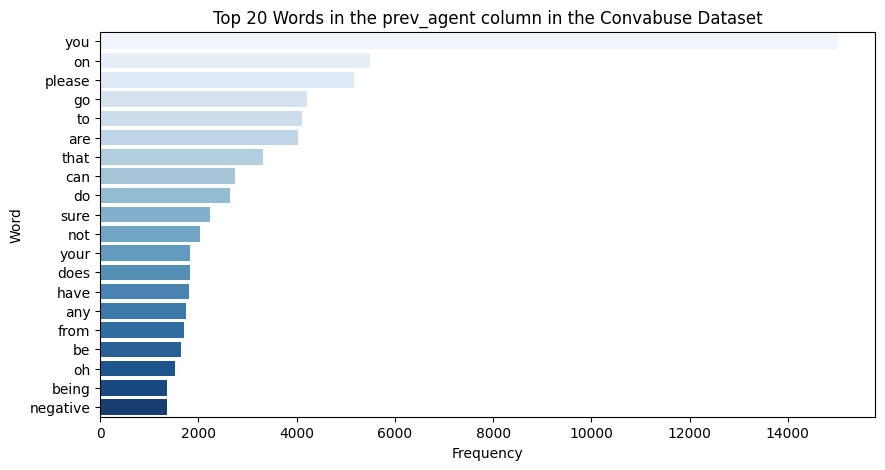

In [70]:
# Plot a horizontal bar chart of the top 20 words in the , sorted in descending order of frequency
plt.figure(figsize=(10, 5))
sns.barplot(y='frequency', x='word', data=convabuse_prev_agent_word_freq.head(20), palette='Blues', hue='frequency')
plt.title('Top 20 Words in the prev_agent column in the Convabuse Dataset')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

In [71]:
# Instantiate the CountVectorizer with ngram_range=(1,1), which indicates unigrams
convabuse_prev_user_cv = CountVectorizer(ngram_range=(1,1))

# Create DTM, which means Document Term Matrix, using CountVectorizer
    # The DTM is a matrix representation of the corpus
convabuse_prev_user_dtm = convabuse_prev_user_cv.fit_transform(convabuse['prev_user'])

# Get the feature names (words) from the CountVectorizer
convabuse_prev_user_words = np.array(convabuse_prev_user_cv.get_feature_names_out())

# Find the 20 most common words in the corpus
convabuse_prev_user_frequencies = convabuse_prev_user_dtm.sum(axis=0).A.flatten()
# Sort the frequencies in descending order and get the indices of the top 20 words
convabuse_prev_user_index = np.argsort(convabuse_prev_user_frequencies)[::-1][:20]
print(list(zip(convabuse_prev_user_words[convabuse_prev_user_index], convabuse_prev_user_frequencies[convabuse_prev_user_index])))

# Create a DataFrame with the words and their frequencies
convabuse_prev_user_word_freq = pd.DataFrame.from_records({'word': convabuse_prev_user_words[convabuse_prev_user_index], 'frequency': convabuse_prev_user_frequencies[convabuse_prev_user_index]})
convabuse_prev_user_word_freq.columns = ['word', 'frequency']

# Get the top 20 words in the corpus
convabuse_prev_user_data = dict(zip(convabuse_prev_user_word_freq['word'].tolist(), convabuse_prev_user_word_freq['frequency'].tolist()))

# Print the top 20 words and their frequencies
for word, freq in convabuse_prev_user_data.items():
    print(f"{word}: {freq}")

[('you', np.int64(6585)), ('fuck', np.int64(2248)), ('to', np.int64(2044)), ('me', np.int64(1942)), ('no', np.int64(1930)), ('yes', np.int64(1882)), ('are', np.int64(1853)), ('my', np.int64(1413)), ('do', np.int64(1395)), ('is', np.int64(1253)), ('what', np.int64(1048)), ('your', np.int64(974)), ('want', np.int64(941)), ('it', np.int64(826)), ('and', np.int64(823)), ('have', np.int64(819)), ('that', np.int64(818)), ('the', np.int64(818)), ('can', np.int64(776)), ('so', np.int64(708))]
6585: you
2248: fuck
2044: to
1942: me
1930: no
1882: yes
1853: are
1413: my
1395: do
1253: is
1048: what
974: your
941: want
826: it
823: and
819: have
818: the
776: can
708: so


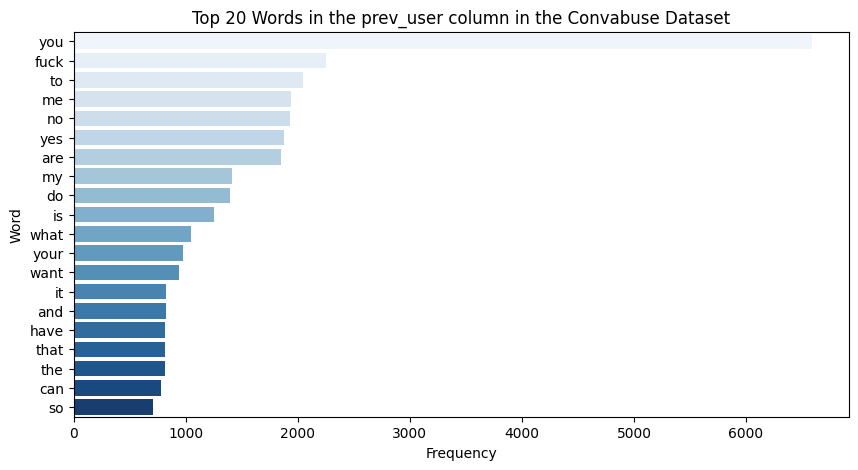

In [72]:
# Plot a horizontal bar chart of the top 20 words in the , sorted in descending order of frequency
plt.figure(figsize=(10, 5))
sns.barplot(y='frequency', x='word', data=convabuse_prev_user_word_freq.head(20), palette='Blues', hue='frequency')
plt.title('Top 20 Words in the prev_user column in the Convabuse Dataset')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

In [73]:
# Instantiate the CountVectorizer with ngram_range=(1,1), which indicates unigrams
convabuse_agent_cv = CountVectorizer(ngram_range=(1,1))

# Create DTM, which means Document Term Matrix, using CountVectorizer
    # The DTM is a matrix representation of the corpus
convabuse_agent_dtm = convabuse_agent_cv.fit_transform(convabuse['agent'])

# Get the feature names (words) from the CountVectorizer
convabuse_agent_words = np.array(convabuse_agent_cv.get_feature_names_out())

# Find the 20 most common words in the corpus
convabuse_agent_frequencies = convabuse_agent_dtm.sum(axis=0).A.flatten()
# Sort the frequencies in descending order and get the indices of the top 20 words
convabuse_agent_index = np.argsort(convabuse_agent_frequencies)[::-1][:20]
print(list(zip(convabuse_agent_words[convabuse_agent_index], convabuse_agent_frequencies[convabuse_agent_index])))

# Create a DataFrame with the words and their frequencies
convabuse_agent_word_freq = pd.DataFrame.from_records({'word': convabuse_agent_words[convabuse_agent_index], 'frequency': convabuse_agent_frequencies[convabuse_agent_index]})
convabuse_agent_word_freq.columns = ['word', 'frequency']

# Get the top 20 words in the corpus
convabuse_agent_data = dict(zip(convabuse_agent_word_freq['word'].tolist(), convabuse_agent_word_freq['frequency'].tolist()))

# Print the top 20 words and their frequencies
for word, freq in convabuse_agent_data.items():
    print(f"{word}: {freq}")

[('you', np.int64(16084)), ('on', np.int64(6892)), ('please', np.int64(6266)), ('go', np.int64(5120)), ('to', np.int64(5093)), ('do', np.int64(3963)), ('are', np.int64(3764)), ('that', np.int64(3486)), ('can', np.int64(3048)), ('your', np.int64(2355)), ('not', np.int64(2311)), ('have', np.int64(2028)), ('sure', np.int64(1880)), ('from', np.int64(1839)), ('why', np.int64(1835)), ('does', np.int64(1749)), ('being', np.int64(1711)), ('elaborate', np.int64(1710)), ('bit', np.int64(1682)), ('negative', np.int64(1648))]
16084: you
6892: on
6266: please
5120: go
5093: to
3963: do
3764: are
3486: that
3048: can
2355: your
2311: not
2028: have
1880: sure
1839: from
1835: why
1749: does
1711: being
1710: elaborate
1682: bit
1648: negative


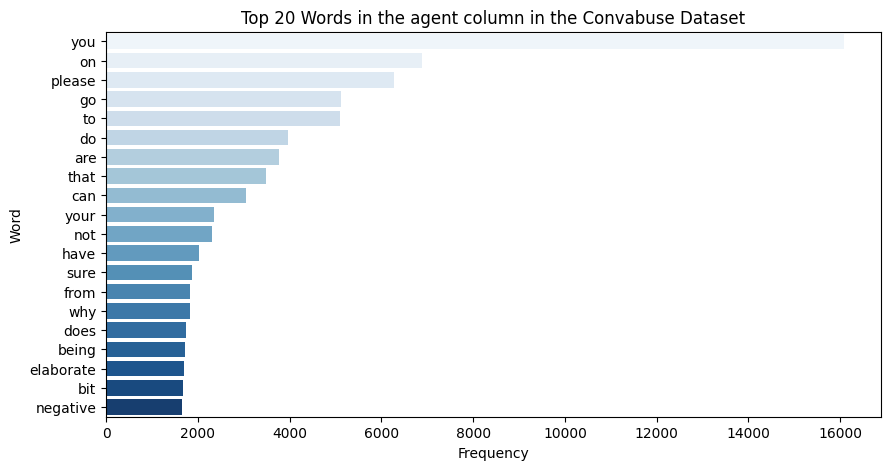

In [74]:
# Plot a horizontal bar chart of the top 20 words in the , sorted in descending order of frequency
plt.figure(figsize=(10, 5))
sns.barplot(y='frequency', x='word', data=convabuse_agent_word_freq.head(20), palette='Blues', hue='frequency')
plt.title('Top 20 Words in the agent column in the Convabuse Dataset')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

In [75]:
# Instantiate the CountVectorizer with ngram_range=(1,1), which indicates unigrams
convabuse_user_cv = CountVectorizer(ngram_range=(1,1))

# Create DTM, which means Document Term Matrix, using CountVectorizer
    # The DTM is a matrix representation of the corpus
convabuse_user_dtm = convabuse_user_cv.fit_transform(convabuse['user'])

# Get the feature names (words) from the CountVectorizer
convabuse_user_words = np.array(convabuse_user_cv.get_feature_names_out())

# Find the 20 most common words in the corpus
convabuse_user_frequencies = convabuse_user_dtm.sum(axis=0).A.flatten()
# Sort the frequencies in descending order and get the indices of the top 20 words
convabuse_user_index = np.argsort(convabuse_user_frequencies)[::-1][:20]
print(list(zip(convabuse_user_words[convabuse_user_index], convabuse_user_frequencies[convabuse_user_index])))

# Create a DataFrame with the words and their frequencies
convabuse_user_word_freq = pd.DataFrame.from_records({'word': convabuse_user_words[convabuse_user_index], 'frequency': convabuse_user_frequencies[convabuse_user_index]})
convabuse_user_word_freq.columns = ['word', 'frequency']

# Get the top 20 words in the corpus
convabuse_user_data = dict(zip(convabuse_user_word_freq['word'].tolist(), convabuse_user_word_freq['frequency'].tolist()))

# Print the top 20 words and their frequencies
for word, freq in convabuse_user_data.items():
    print(f"{word}: {freq}")

[('you', np.int64(10087)), ('fuck', np.int64(4059)), ('to', np.int64(2477)), ('are', np.int64(2375)), ('yes', np.int64(1852)), ('me', np.int64(1775)), ('the', np.int64(1491)), ('your', np.int64(1488)), ('my', np.int64(1257)), ('do', np.int64(1135)), ('no', np.int64(1129)), ('bitch', np.int64(1116)), ('is', np.int64(1070)), ('want', np.int64(1009)), ('what', np.int64(949)), ('it', np.int64(896)), ('and', np.int64(835)), ('kill', np.int64(813)), ('in', np.int64(808)), ('am', np.int64(746))]
10087: you
4059: fuck
2477: to
2375: are
1852: yes
1775: me
1491: the
1488: your
1257: my
1135: do
1129: no
1116: bitch
1070: is
1009: want
949: what
896: it
835: and
813: kill
808: in
746: am


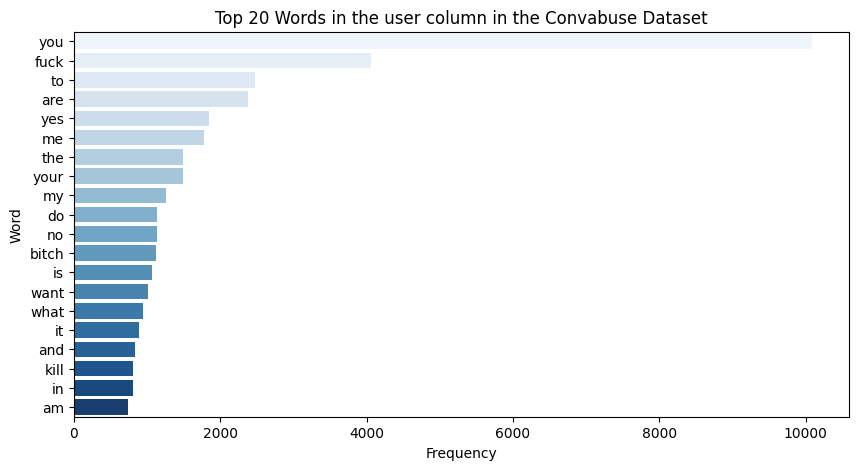

In [76]:
# Plot a horizontal bar chart of the top 20 words in the , sorted in descending order of frequency
plt.figure(figsize=(10, 5))
sns.barplot(y='frequency', x='word', data=convabuse_user_word_freq.head(20), palette='Blues', hue='frequency')
plt.title('Top 20 Words in the user column in the Convabuse Dataset')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

In [77]:
# Instantiate the CountVectorizer with ngram_range=(1,1), which indicates unigrams
dghs_cv = CountVectorizer(ngram_range=(1,1))

# Create DTM, which means Document Term Matrix, using CountVectorizer
    # The DTM is a matrix representation of the corpus
dghs_dtm = dghs_cv.fit_transform(dghs['text'])

# Get the feature names (words) from the CountVectorizer
dghs_words = np.array(dghs_cv.get_feature_names_out())

# Find the 20 most common words in the corpus
dghs_frequencies = dghs_dtm.sum(axis=0).A.flatten()
# Sort the frequencies in descending order and get the indices of the top 20 words
dghs_index = np.argsort(dghs_frequencies)[::-1][:20]
print(list(zip(dghs_words[dghs_index], dghs_frequencies[dghs_index])))

# Create a DataFrame with the words and their frequencies
dghs_word_freq = pd.DataFrame.from_records({'word': dghs_words[dghs_index], 'frequency': dghs_frequencies[dghs_index]})
dghs_word_freq.columns = ['word', 'frequency']

# Get the top 20 words in the corpus
dghs_data = dict(zip(dghs_word_freq['word'].tolist(), dghs_word_freq['frequency'].tolist()))

# Print the top 20 words and their frequencies
for word, freq in dghs_data.items():
    print(f"{word}: {freq}")

[('the', np.int64(32693)), ('to', np.int64(25193)), ('and', np.int64(21429)), ('of', np.int64(17066)), ('is', np.int64(14820)), ('are', np.int64(14511)), ('that', np.int64(12598)), ('you', np.int64(12437)), ('it', np.int64(12157)), ('in', np.int64(11811)), ('they', np.int64(11434)), ('be', np.int64(7708)), ('people', np.int64(7678)), ('not', np.int64(7270)), ('for', np.int64(7194)), ('this', np.int64(6729)), ('have', np.int64(6388)), ('all', np.int64(6181)), ('with', np.int64(6146)), ('as', np.int64(5198))]
32693: the
25193: to
21429: and
17066: of
14820: is
14511: are
12598: that
12437: you
12157: it
11811: in
11434: they
7708: be
7678: people
7270: not
7194: for
6729: this
6388: have
6181: all
6146: with
5198: as


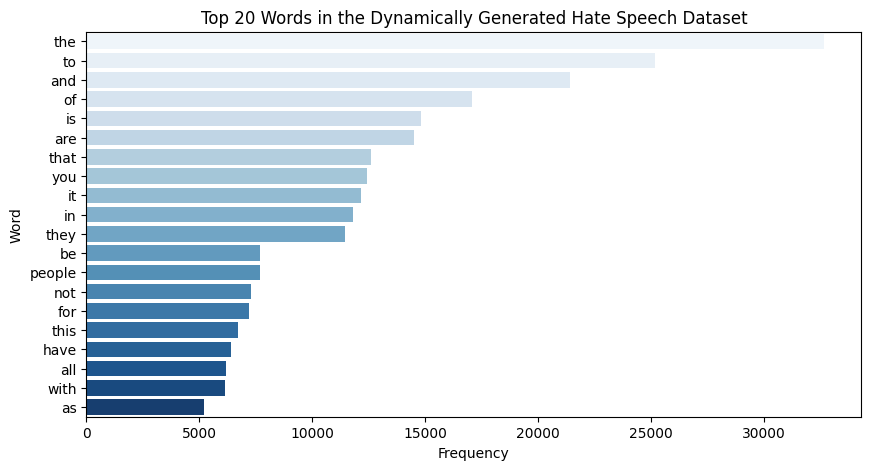

In [78]:
# Plot a horizontal bar chart of the top 20 words in the , sorted in descending order of frequency
plt.figure(figsize=(10, 5))
sns.barplot(y='frequency', x='word', data=dghs_word_freq.head(20), palette='Blues', hue='frequency')
plt.title('Top 20 Words in the Dynamically Generated Hate Speech Dataset')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

In [79]:
# Instantiate the CountVectorizer with ngram_range=(1,1), which indicates unigrams
mlma_hate_speech_cv = CountVectorizer(ngram_range=(1,1))

# Create DTM, which means Document Term Matrix, using CountVectorizer
    # The DTM is a matrix representation of the corpus
mlma_hate_speech_dtm = mlma_hate_speech_cv.fit_transform(mlma_hate_speech['tweet'])

# Get the feature names (words) from the CountVectorizer
mlma_hate_speech_words = np.array(mlma_hate_speech_cv.get_feature_names_out())

# Find the 20 most common words in the corpus
mlma_hate_speech_frequencies = mlma_hate_speech_dtm.sum(axis=0).A.flatten()
# Sort the frequencies in descending order and get the indices of the top 20 words
mlma_hate_speech_index = np.argsort(mlma_hate_speech_frequencies)[::-1][:20]
print(list(zip(mlma_hate_speech_words[mlma_hate_speech_index], mlma_hate_speech_frequencies[mlma_hate_speech_index])))

# Create a DataFrame with the words and their frequencies
mlma_hate_speech_word_freq = pd.DataFrame.from_records({'word': mlma_hate_speech_words[mlma_hate_speech_index], 'frequency': mlma_hate_speech_frequencies[mlma_hate_speech_index]})
mlma_hate_speech_word_freq.columns = ['word', 'frequency']

# Get the top 20 words in the corpus
mlma_hate_speech_data = dict(zip(mlma_hate_speech_word_freq['word'].tolist(), mlma_hate_speech_word_freq['frequency'].tolist()))

# Print the top 20 words and their frequencies
for word, freq in mlma_hate_speech_data.items():
    print(f"{word}: {freq}")

[('user', np.int64(8874)), ('url', np.int64(4684)), ('the', np.int64(1868)), ('you', np.int64(1620)), ('to', np.int64(1397)), ('retard', np.int64(1259)), ('retarded', np.int64(1249)), ('and', np.int64(1153)), ('faggot', np.int64(1116)), ('is', np.int64(1101)), ('u2026', np.int64(1082)), ('shithole', np.int64(980)), ('cunt', np.int64(973)), ('twat', np.int64(891)), ('that', np.int64(841)), ('ud83d', np.int64(802)), ('like', np.int64(791)), ('it', np.int64(786)), ('of', np.int64(775)), ('in', np.int64(735))]
8874: user
4684: url
1868: the
1620: you
1397: to
1259: retard
1249: retarded
1153: and
1116: faggot
1101: is
1082: u2026
980: shithole
973: cunt
891: twat
841: that
802: ud83d
791: like
786: it
775: of
735: in


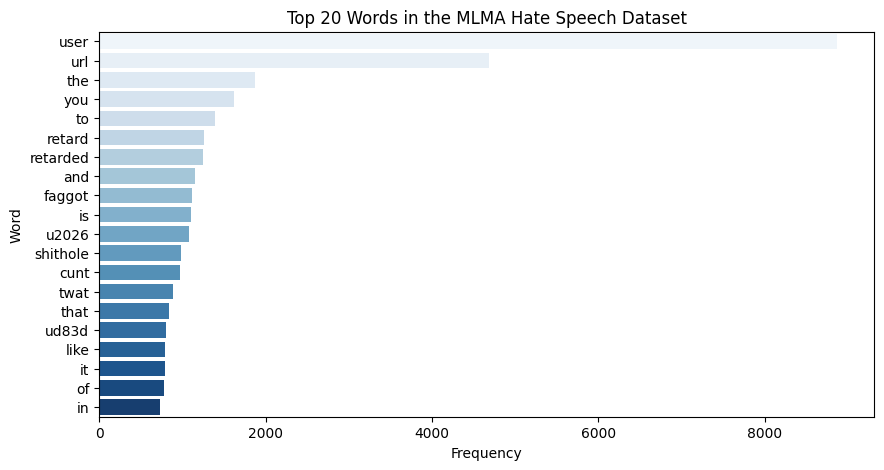

In [80]:
# Plot a horizontal bar chart of the top 20 words in the , sorted in descending order of frequency
plt.figure(figsize=(10, 5))
sns.barplot(y='frequency', x='word', data=mlma_hate_speech_word_freq.head(20), palette='Blues', hue='frequency')
plt.title('Top 20 Words in the MLMA Hate Speech Dataset')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()